In [2]:
using LinearAlgebra
using Distributions
using Plots
using Statistics
using Parameters
using Random

Random.seed!(123)

println("Packages loaded successfully")

Packages loaded successfully


## The Small Open Economy New Keynesian Model

New Keynesian model for a small open economy from **Galí (2015, Chapter 7)**. The model consists of:

**1. Dynamic IS Equation (Aggregate Demand):**
$$\tilde{y}_t = E_t\{\tilde{y}_{t+1}\} - \frac{1}{\sigma_\alpha}(i_t - E_t\{\pi_{H,t+1}\} - r_t^n) \ (38) $$ 

Output gap depends on expected future output and the real interest rate gap (nominal rate minus expected inflation minus natural rate).

**2. New Keynesian Phillips Curve (Aggregate Supply):**
$$\pi_{H,t} = \beta E_t\{\pi_{H,t+1}\} + \kappa_\alpha \tilde{y}_t \ (37) $$ 

Domestic inflation depends on expected future inflation and the current output gap. The coefficient $\kappa_\alpha = \lambda(\sigma_\alpha + \varphi)$ reflects price stickiness.

**3. Monetary Policy Rule (Taylor Rule):**
$$i_t = \rho + \phi_\pi \pi_{H,t} + \phi_y \tilde{y}_t + v_t  \ (40) $$


The central bank sets the nominal interest rate responding to inflation and output gap, plus a monetary policy shock $v_t$.

**Natural Rate of Interest:**
$$r_t^n = \rho - \sigma_\alpha \Gamma_a(1-\rho_a)a_t + \frac{\alpha\Theta\sigma_\alpha\varphi}{\sigma_\alpha + \varphi} E_t\{\Delta y^*_{t+1}\} \ (39) $$

The natural rate (flexible-price equilibrium rate) depends on productivity shocks $a_t$ and expected world output growth $E_t\{\Delta y^*_{t+1}\}$.

## Matrix Representation

We express the system in matrix form:
$$A_0 y_t = A_1 E_t\{y_{t+1}\} + A_2 z_t + A_3$$

**Variables:**
- Endogenous: $y_t = [\tilde{y}_t, \pi_{H,t}, i_t]'$ 
- Exogenous shocks: $z_t = [a_t, v_t, y^*_t]'$

**Coefficient Matrices:**

$$A_0 = \begin{bmatrix} 
1 & 0 & \frac{1}{\sigma_\alpha} \\
-\kappa_\alpha & 1 & 0 \\
-\phi_y & -\phi_\pi & 1
\end{bmatrix}$$

$$A_1 = \begin{bmatrix} 
1 & \frac{1}{\sigma_\alpha} & 0 \\
0 & \beta & 0 \\
0 & 0 & 0
\end{bmatrix}$$

$$A_2 = \begin{bmatrix} 
\frac{\psi_a}{\sigma_\alpha} & 0 & \frac{\psi_{y^*}(\rho_{y^*}-1)}{\sigma_\alpha} \\
0 & 0 & 0 \\
0 & 1 & 0
\end{bmatrix}$$

$$A_3 = \begin{bmatrix} 
\frac{\rho}{\sigma_\alpha} \\ 
0 \\ 
\rho 
\end{bmatrix}$$

where $\psi_a = -\sigma_\alpha \Gamma_a(1-\rho_a)$ and $\psi_{y^*} = \frac{\alpha\Theta\sigma_\alpha\varphi}{\sigma_\alpha + \varphi}$.

## Parameter Calibration - Galí (2015, Chapter 7, Section 7.5.1.1, p. 174)

**Primitives**
- $\sigma = \eta = \gamma = 1$ - preferences/substitutabilities, baseline special case (definitions pp. 152, 154; values p. 174)
- $\varphi = 3.0$ - inverse Frisch elasticity of labor supply, elasticity 1/3 (p. 154; value p. 174)
- $\beta = 0.99$ - quarterly discount factor, ~4% annual rate (eq. 1, p. 151; value p. 174)
- $\theta = 0.75$ - Calvo probability of keeping prices fixed, average duration 4 quarters (p. 174)
- $\alpha = 0.4$ - openness / import share, matching Canada's import/GDP ratio (p. 152; value p. 174)

**Derived composites**
- $\lambda = \frac{(1-\beta\theta)(1-\theta)}{\theta} \approx 0.0858$ - inflation-marginal cost slope (def. after eq. 33, p. 163)
- $\omega = \sigma\gamma + (1-\alpha)(\sigma\eta - 1) = 1$ (def. after eq. 27, p. 161)
- $\Theta = \omega - 1 = 0$ (def. after eq. 30, pp. 161-162)
- $\sigma_\alpha = \frac{\sigma}{1+\alpha(\omega-1)} = 1$ - open-economy IS slope (def. after eq. 29, p. 161)
- $\Gamma_a = \frac{1+\varphi}{\sigma_\alpha+\varphi} = 1$ - natural output elasticity w.r.t. productivity (def. after eq. 36, p. 164)
- $\kappa_\alpha = \lambda(\sigma_\alpha + \varphi) \approx 0.343$ - NKPC slope (def. after eq. 37, p. 164)

**Monetary Policy**
- $\phi_\pi = 1.5$ - original Taylor calibration (p. 174)
- $\phi_y = 0$ - DITR (sec. 7.5, p. 173)
- $v_t = 0$ - no policy shock in the sec. 7.5 experiments ($\sigma_v = 0$)
- $\rho = -\log(\beta) \approx 0.0101$ - steady-state real interest rate

**Shock Processes (p. 174)**
- **Productivity:** $a_t = 0.66\, a_{t-1} + \varepsilon^a_t$, with $\sigma_a = 0.0071$
- **World output:** $y^*_t = 0.86\, y^*_{t-1} + \varepsilon^{y^*}_t$, with $\sigma_{y^*} = 0.0078$
- **Correlation:** $\text{corr}(\varepsilon^a_t, \varepsilon^{y^*}_t) = 0.3$

In [4]:
# Primitives (Gali 2015, sec. 7.5.1.1, p. 174)
σ = 1.0        # inverse IES, utility curvature (p. 154)
η = 1.0        # substitutability home vs. foreign goods (p. 152)
γ = 1.0        # substitutability across foreign countries (p. 152)
φ = 3.0        # inverse Frisch elasticity (p. 154)
β = 0.99       # discount factor (eq. 1, p. 151)
θ = 0.75       # Calvo prob. of no price reset (p. 174)
α = 0.4        # openness (p. 152; value p. 174)

# Derived composites
λ   = (1 - β*θ) * (1 - θ) / θ     # def. after eq. 33, p. 163; ≈ 0.0858
ω   = σ*γ + (1 - α)*(σ*η - 1)     # def. after eq. 27, p. 161; = 1 at baseline
Θ   = ω - 1                       # def. after eq. 30, pp. 161-162; = 0 at baseline
σ_α = σ / (1 + α*(ω - 1))         # def. after eq. 29, p. 161; = 1 at baseline
Γ_a = (1 + φ) / (σ_α + φ)         # def. after eq. 36, p. 164; = 1 at baseline
κ_α = λ * (σ_α + φ)               # def. after eq. 37, p. 164; ≈ 0.343

# Monetary policy: DITR (sec. 7.5, p. 173)
φ_π = 1.5                         # p. 174
φ_y = 0.0                         # DITR: no output gap response
ρ   = -log(β)                     # steady-state real rate

# Shock processes (p. 174)
ρ_a      = 0.66                   # productivity AR(1)
ρ_y_star = 0.86                   # world output AR(1)
σ_a      = 0.0071
σ_y_star = 0.0078
ρ_corr   = 0.3
σ_v      = 0.0                    # no policy shock in sec. 7.5 experiments

# Natural rate coefficients (eq. 39, p. 165)
ψ_a      = -σ_α * Γ_a * (1 - ρ_a)
ψ_y_star = (α * Θ * σ_α * φ) / (σ_α + φ)

#-----------------------------------------------------------------------------------------------------------------
println("=" ^ 60)
println("\nPrimitives:")
println("  σ = $σ, η = $η, γ = $γ")
println("  φ = $φ (inverse Frisch)")
println("  β = $β")
println("  θ = $θ (Calvo - avg price duration = $(round(1/(1-θ), digits=1)) quarters)")
println("  α = $α (openness)")
println("\nDerived:")
println("  λ = $(round(λ, digits=4))")
println("  ω = $ω, Θ = $Θ")
println("  σ_α = $σ_α, Γ_a = $Γ_a")
println("  κ_α = $(round(κ_α, digits=4)) (NKPC slope)")
println("\nMonetary Policy (DITR):")
println("  phi_pi = $(φ_π), phi_y = $(φ_y)")
println("\nShock Processes:")
println("  rho_a = $(ρ_a), sigma_a = $(σ_a)")
println("  rho_y* = $(ρ_y_star), sigma_y* = $(σ_y_star)")
println("  corr = $(ρ_corr), sigma_v = $(σ_v)")
println("\nNatural rate coefficients:")
println("  psi_a = $(round(ψ_a, digits=4))")
println("  psi_y* = $(round(ψ_y_star, digits=4))")
println("=" ^ 60)


Primitives:
  σ = 1.0, η = 1.0, γ = 1.0
  φ = 3.0 (inverse Frisch)
  β = 0.99
  θ = 0.75 (Calvo - avg price duration = 4.0 quarters)
  α = 0.4 (openness)

Derived:
  λ = 0.0858
  ω = 1.0, Θ = 0.0
  σ_α = 1.0, Γ_a = 1.0
  κ_α = 0.3433 (NKPC slope)

Monetary Policy (DITR):
  phi_pi = 1.5, phi_y = 0.0

Shock Processes:
  rho_a = 0.66, sigma_a = 0.0071
  rho_y* = 0.86, sigma_y* = 0.0078
  corr = 0.3, sigma_v = 0.0

Natural rate coefficients:
  psi_a = -0.34
  psi_y* = 0.0


In [5]:
# Natural rate coefficients
ψ_a = -σ_α * Γ_a * (1 - ρ_a)
ψ_y_star = (α * Θ * σ_α * φ) / (σ_α + φ)

println("\nNatural rate coefficients:")
println("  ψ_a = $(round(ψ_a, digits=4))")
println("  ψ_y* = $(round(ψ_y_star, digits=4))")

# A0: Current endogenous variables
A0 = [1.0        0.0         1/σ_α;
      -κ_α       1.0         0.0;
      -φ_y       -φ_π        1.0]

# A1: Expected future endogenous
A1 = [1.0        1/σ_α       0.0;
      0.0        β           0.0;
      0.0        0.0         0.0]

# A2: Shocks [a_t, v_t, y*_t]
A2 = [ψ_a/σ_α    0.0         (ψ_y_star * (ρ_y_star - 1))/σ_α;
      0.0        0.0         0.0;
      0.0        1.0         0.0]

# A3: Constants
A3 = [ρ/σ_α; 0.0; ρ]

#------------------------------------------------------------------------------------
println("\n" * "=" ^ 50)
println("\nA0:")
display(round.(A0, digits=4))
println("\nA1:")
display(round.(A1, digits=4))
println("\nA2:")
display(round.(A2, digits=4))
println("\nA3:")
display(round.(A3, digits=4))
println("=" ^ 50)


Natural rate coefficients:
  ψ_a = -0.34
  ψ_y* = 0.0


A0:


3×3 Matrix{Float64}:
  1.0      0.0  1.0
 -0.3433   1.0  0.0
 -0.0     -1.5  1.0


A1:


3×3 Matrix{Float64}:
 1.0  1.0   0.0
 0.0  0.99  0.0
 0.0  0.0   0.0


A2:


3×3 Matrix{Float64}:
 -0.34  0.0  -0.0
  0.0   0.0   0.0
  0.0   1.0   0.0


A3:


3-element Vector{Float64}:
 0.0101
 0.0
 0.0101

In [6]:
# Shock persistence matrix
Φ = [ρ_a  0.0  0.0;
     0.0  0.0  0.0;          # v_t: iid (and switched off)
     0.0  0.0  ρ_y_star]

# Steady state: (A0 - A1) * C̄ = A3
C_bar = (A0 - A1) \ A3

# REE coefficients: column j solves (A0 - Φ[j,j]*A1) * c_j = A2[:,j]
C = zeros(3, 3)
for j in 1:3
    C[:, j] = (A0 - Φ[j,j] * A1) \ A2[:, j]
end

println("Steady state C̄ = ", round.(C_bar, digits=4))
println("\nREE coefficient matrix C (columns: a, v, y*):")
display(round.(C, digits=4))

# Verification: residual of A0*C - A1*C*Φ - A2 must be ~0
resid = A0*C - A1*C*Φ - A2
println("\nmax |residual| = ", maximum(abs.(resid)))

Steady state C̄ = [-0.0, -0.0, 0.0101]

REE coefficient matrix C (columns: a, v, y*):


3×3 Matrix{Float64}:
 -0.2901  -0.6601  -0.0
 -0.2873  -0.2266  -0.0
 -0.431    0.6601   0.0


max |residual| = 5.551115123125783e-17


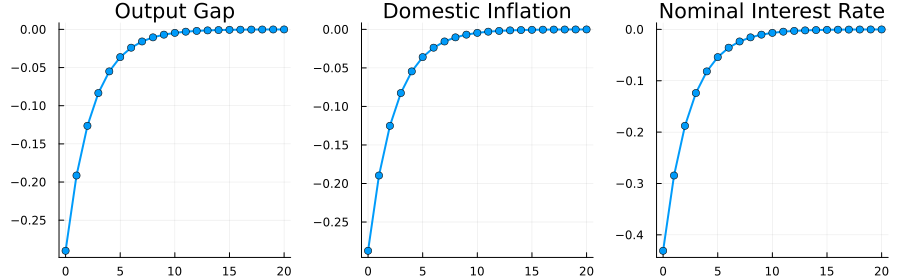

In [7]:
H = 20
horizon = 0:H
a_path = [ρ_a^h for h in horizon]      # a_t after unit innovation
irf = C[:, 1] * a_path'                # 3×21: rows = ỹ, π_H, i

p1 = plot(horizon, irf[1, :], marker=:circle, label="", title="Output Gap")
p2 = plot(horizon, irf[2, :], marker=:circle, label="", title="Domestic Inflation")
p3 = plot(horizon, irf[3, :], marker=:circle, label="", title="Nominal Interest Rate")
plot(p1, p2, p3, layout=(1,3), size=(900,280), lw=2)